# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
df = pd.read_csv('../data/House_Rent_Dataset.csv', sep=None, engine='python')

In [3]:
df.shape

(4746, 12)

In [4]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [28]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_percent

Posted On            0.0
BHK                  0.0
Rent                 0.0
Size                 0.0
Floor                0.0
Area Type            0.0
Area Locality        0.0
City                 0.0
Furnishing Status    0.0
Tenant Preferred     0.0
Bathroom             0.0
Point of Contact     0.0
Rent_log             0.0
dtype: float64

In [19]:
stats = df.describe()
stats.round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


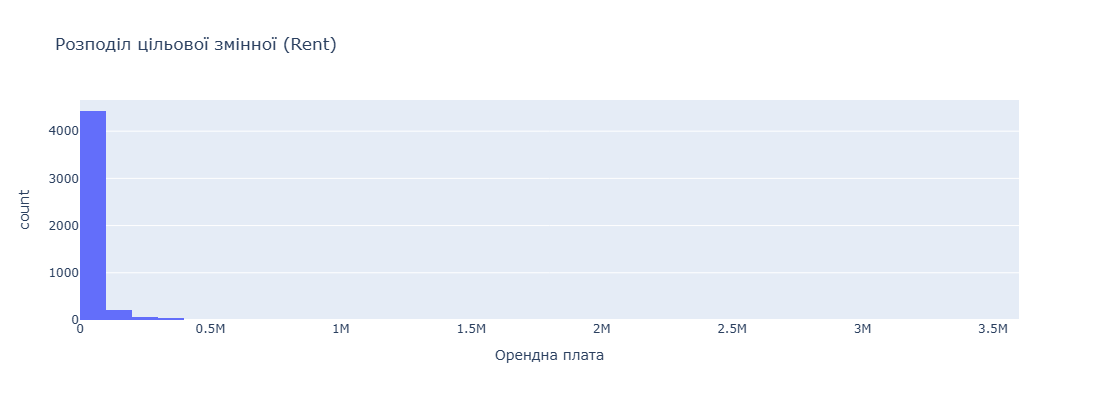

In [20]:
fig = px.histogram(
    df,
    x='Rent',
    nbins=50,
    title='Розподіл цільової змінної (Rent)',
    labels={'Rent': 'Орендна плата', 'count': 'Кількість оренд'}
)
fig.update_layout(
    showlegend=False,
    height=400
)
fig.show()

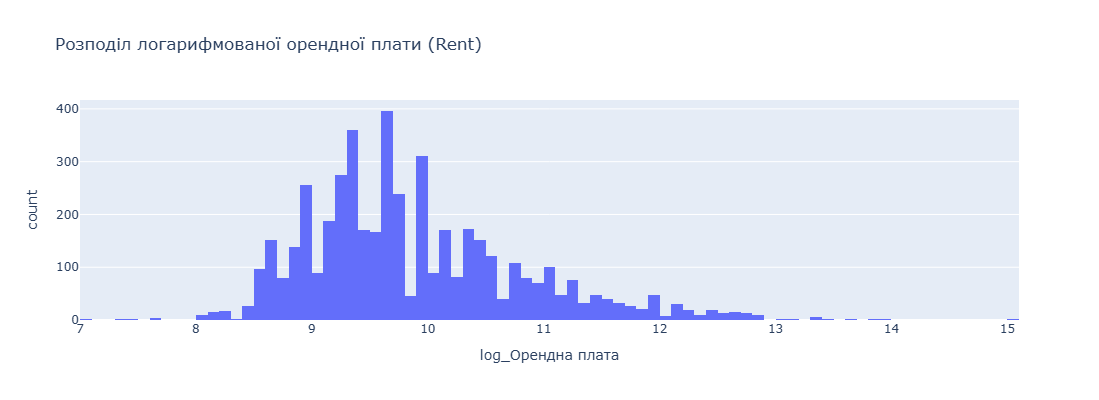

In [25]:
df['Rent_log'] = np.log1p(df['Rent'])
fig = px.histogram(
    df,
    x='Rent_log',
    nbins=100,
    title='Розподіл логарифмованої орендної плати (Rent)',
    labels={'Rent_log': 'log_Орендна плата', 'count': 'Кількість оренд'}
)
fig.update_layout(
    showlegend=False,
    height=400
)
fig.show()

In [30]:
# Знаходимо квартилі
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

# Межі для викидів
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Нижня межа для Rent: {lower_bound}")
print(f"Верхня межа для Rent: {upper_bound}")

# Перевіряємо які рядки є викидами
outliers = df[(df['Rent'] < lower_bound) | (df['Rent'] > upper_bound)]
print(f"Кількість викидів: {len(outliers)}")
outliers.head()  # показати перші 5 викидів

# Видаляємо викиди
df_clean = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)].copy()
print(f"Розмір датасету після видалення викидів: {df_clean.shape}")

Нижня межа для Rent: -24500.0
Верхня межа для Rent: 67500.0
Кількість викидів: 520
Розмір датасету після видалення викидів: (4226, 13)


In [31]:
df[(df['Rent'] < lower_bound) | (df['Rent'] > upper_bound)]

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Rent_log
104,2022-06-16,2,180000,950,Ground out of 1,Carpet Area,"Avenue S, Santoshpur",Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,12.100718
525,2022-06-14,2,70000,750,4 out of 10,Carpet Area,Santacruz West,Mumbai,Furnished,Bachelors/Family,2,Contact Agent,11.156265
527,2022-05-27,3,75000,1100,2 out of 13,Carpet Area,"Sabari Palm View, Chembur",Mumbai,Unfurnished,Family,3,Contact Agent,11.225257
530,2022-06-20,2,160000,800,14 out of 14,Carpet Area,parivar safalya chs,Mumbai,Unfurnished,Bachelors/Family,2,Contact Owner,11.982935
531,2022-07-07,4,300000,1600,43 out of 78,Carpet Area,"Trump Tower, Worli",Mumbai,Semi-Furnished,Bachelors/Family,5,Contact Agent,12.611541
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4523,2022-06-21,3,70000,2780,4 out of 26,Super Area,Nanakram Guda,Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,11.156265
4543,2022-06-11,4,200000,4761,1 out of 35,Carpet Area,K P H B Phase 4,Hyderabad,Semi-Furnished,Bachelors,6,Contact Owner,12.206078
4648,2022-07-06,6,80000,4500,1 out of 2,Super Area,"Kakateeya Nagar, Secunderabad",Hyderabad,Semi-Furnished,Bachelors/Family,6,Contact Owner,11.289794
4669,2022-07-06,4,140000,3789,9 out of 22,Carpet Area,"Gachibowli CUC, Outer Ring Road",Hyderabad,Semi-Furnished,Family,5,Contact Agent,11.849405


In [32]:
# Визначаємо категоріальні колонки
categorical_cols = df_clean.select_dtypes(include='object').columns
print("Категоріальні колонки:", list(categorical_cols))

# Виводимо кількість унікальних значень для кожної
for col in categorical_cols:
    print(f"{col}: {df_clean[col].nunique()} унікальних значень")

Категоріальні колонки: ['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']
Posted On: 80 унікальних значень
Floor: 340 унікальних значень
Area Type: 3 унікальних значень
Area Locality: 1997 унікальних значень
City: 6 унікальних значень
Furnishing Status: 3 унікальних значень
Tenant Preferred: 3 унікальних значень
Point of Contact: 3 унікальних значень



## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
metrics_df = df_clean[['BHK', 'Rent', 'Size', 'Bathroom']].dropna()

corr_matrix = metrics_df.corr()
print(corr_matrix)

               BHK      Rent      Size  Bathroom
BHK       1.000000  0.401268  0.698453  0.747918
Rent      0.401268  1.000000  0.393605  0.506528
Size      0.698453  0.393605  1.000000  0.680607
Bathroom  0.747918  0.506528  0.680607  1.000000


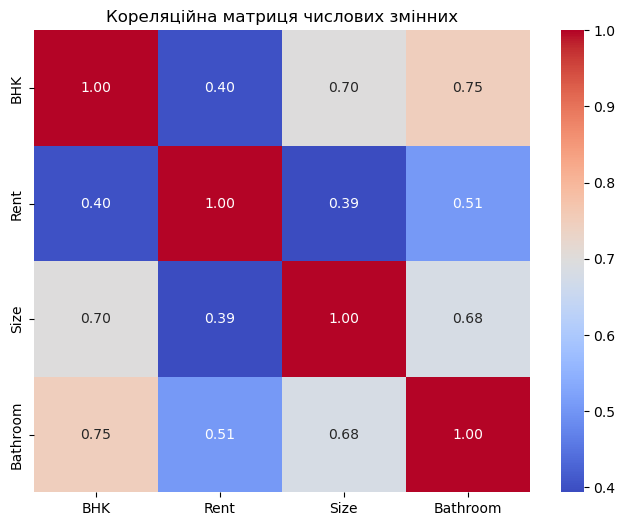

In [45]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Кореляційна матриця числових змінних")
plt.show()

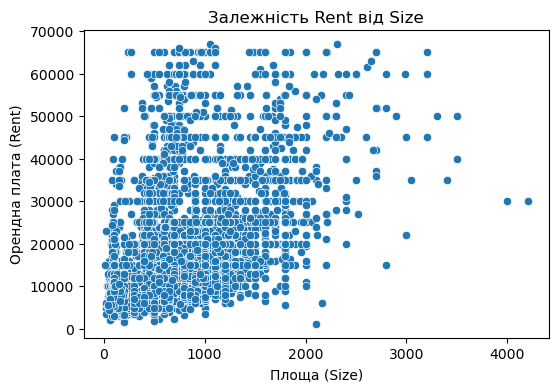

In [46]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x='Size', y='Rent')
plt.title("Залежність Rent від Size")
plt.xlabel("Площа (Size)")
plt.ylabel("Орендна плата (Rent)")
plt.show()

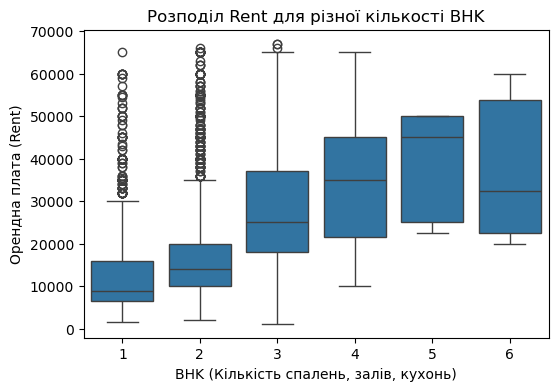

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_clean, x='BHK', y='Rent')
plt.title("Розподіл Rent для різної кількості BHK")
plt.xlabel("BHK (Кількість спалень, залів, кухонь)")
plt.ylabel("Орендна плата (Rent)")
plt.show()

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [88]:
# 1. Encoding
df_encoded = pd.get_dummies(df_clean, 
                           columns=['City', 'Furnishing Status', 'Tenant Preferred', 'Area Type'], 
                           drop_first=True)

In [89]:
# 2. Нові фічі
df_encoded['price_per_sqft'] = df_encoded['Rent'] / df_encoded['Size']
df_encoded['bathroom_per_room'] = df_encoded['Bathroom'] / df_encoded['BHK']

In [90]:
# 3. Видалення зайвого
df_encoded = df_encoded.drop(columns=['Rent', 'Area Locality', 'Point of Contact', 'Posted On', 'Floor'])

In [91]:
# 4. X, y
X = df_encoded.drop(columns=['Rent_log'])
y = df_encoded['Rent_log']

print(f"\nРозмір X (ознак): {X.shape}")
print(f"Розмір y (цілі): {y.shape}")


Розмір X (ознак): (4226, 16)
Розмір y (цілі): (4226,)


In [92]:
# 5. Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[num_cols] = scaler.fit_transform(X[num_cols])

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [94]:
X.dtypes

BHK                                  float64
Size                                 float64
Bathroom                             float64
City_Chennai                            bool
City_Delhi                              bool
City_Hyderabad                          bool
City_Kolkata                            bool
City_Mumbai                             bool
Furnishing Status_Semi-Furnished        bool
Furnishing Status_Unfurnished           bool
Tenant Preferred_Bachelors/Family       bool
Tenant Preferred_Family                 bool
Area Type_Carpet Area                   bool
Area Type_Super Area                    bool
price_per_sqft                       float64
bathroom_per_room                    float64
dtype: object

In [95]:
from sklearn.linear_model import LinearRegression

# Створюємо модель
model = LinearRegression()

# Навчаємо модель на навчальних даних
model.fit(X_train, y_train)

LinearRegression()

In [96]:
# Виводимо ваги для кожної ознаки
for feature, weight in zip(model.feature_names_in_, model.coef_):
    print(f"{feature}: {weight:.2f}")

print(f"\nЗміщення (intercept): {model.intercept_:.2f}")

BHK: 0.09
Size: 0.32
Bathroom: 0.08
City_Chennai: -0.04
City_Delhi: 0.04
City_Hyderabad: -0.16
City_Kolkata: -0.25
City_Mumbai: 0.83
Furnishing Status_Semi-Furnished: -0.14
Furnishing Status_Unfurnished: -0.23
Tenant Preferred_Bachelors/Family: -0.06
Tenant Preferred_Family: -0.07
Area Type_Carpet Area: 0.18
Area Type_Super Area: 0.05
price_per_sqft: 0.22
bathroom_per_room: -0.01

Зміщення (intercept): 9.70


City_Mumbai - 0.83
Size - 0.32
Місце розташування та площа — найбільш впливають на розмір орендної плати.

In [98]:
# Прогнози на навчальній вибірці
y_train_pred = model.predict(X_train)

# Прогнози на тестовій вибірці (нові дані!)
y_test_pred = model.predict(X_test)

# Порівняння перших 10 прогнозів з реальністю
comparison = pd.DataFrame({
    'Реальна оренда': y_test.values[:10],
    'Прогнозована оренда': y_test_pred[:10].round(0),
    'Помилка': (y_test.values[:10] - y_test_pred[:10]).round(0)
})
print("Приклади прогнозів на тестовій вибірці:")
print(comparison)

Приклади прогнозів на тестовій вибірці:
   Реальна оренда  Прогнозована оренда  Помилка
0        9.998843                 10.0     -0.0
1        8.517393                  9.0     -0.0
2       10.518700                 11.0     -0.0
3        8.987322                  9.0      0.0
4        9.615872                  9.0      0.0
5        9.903538                 10.0      0.0
6        9.047939                  9.0     -0.0
7        8.853808                  9.0      0.0
8        8.006701                  8.0     -0.0
9        8.987322                  9.0      0.0


## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Розраховуємо метрики для тестової вибірки
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):")
print("="*50)
print(f"\nMAE: {mae:.2f} ")
print(f"RMSE: {rmse:.2f} ")
print(f"R²: {r2:.3f}")

# Порівняння з навчальною вибіркою
mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train, y_train_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:")
print("="*50)
print(f"\nMAE: {mae:.2f} ")
print(f"RMSE: {rmse:.2f} ")
print(f"R²: {r2_train:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):

MAE: 0.26 
RMSE: 0.40 
R²: 0.640
МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:

MAE: 0.26 
RMSE: 0.34 
R²: 0.729


Модель адекватно прогнозує оренду: вона трохи краще навчається на тренувальних даних, ніж на тестових, але різниця невелика. Це означає, що перенавчання відсутнє, а недонавчання теж не спостерігається. 

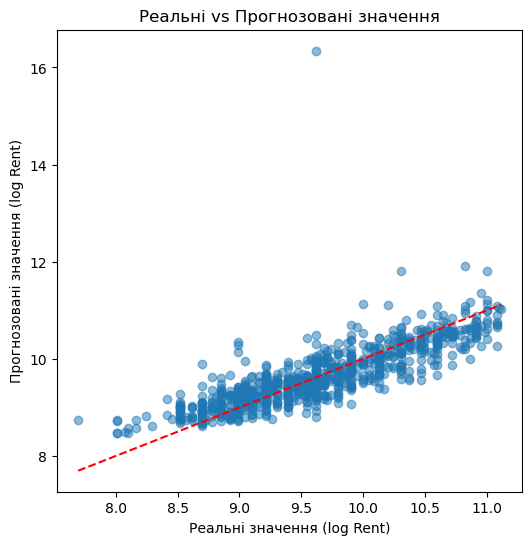

In [102]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # лінія ідеальної відповідності
plt.xlabel("Реальні значення (log Rent)")
plt.ylabel("Прогнозовані значення (log Rent)")
plt.title("Реальні vs Прогнозовані значення")
plt.show()

Точки щільно лежать на червоній діагоналі, отже, модель добре передбачає

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

In [104]:
# Помилка = реальне - прогнозоване
residuals = y_test - y_test_pred

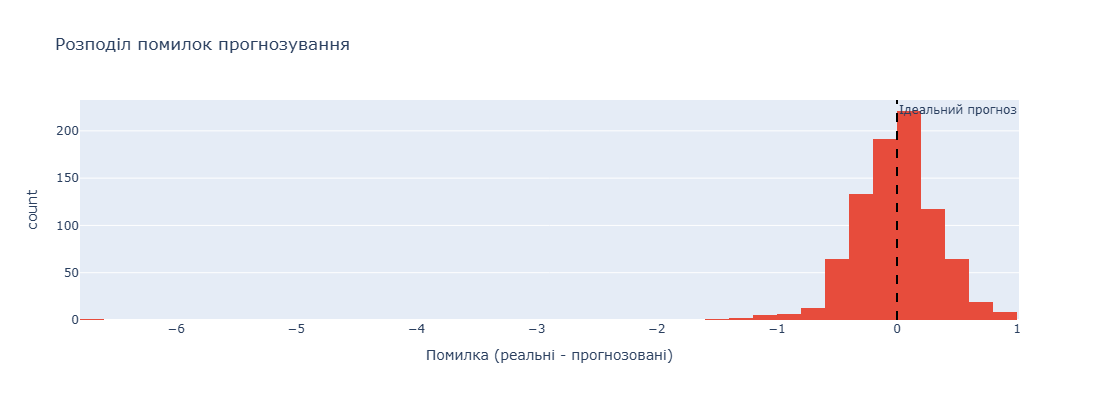

In [106]:
residuals = y_test - y_test_pred

# Гістограма помилок
fig = px.histogram(
    x=residuals,
    nbins=50,
    title='Розподіл помилок прогнозування',
    labels={'x': 'Помилка (реальні - прогнозовані)', 'count': 'Кількість'},
    color_discrete_sequence=['#e74c3c']
)
fig.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Ідеальний прогноз")
fig.update_layout(height=400)
fig.show()

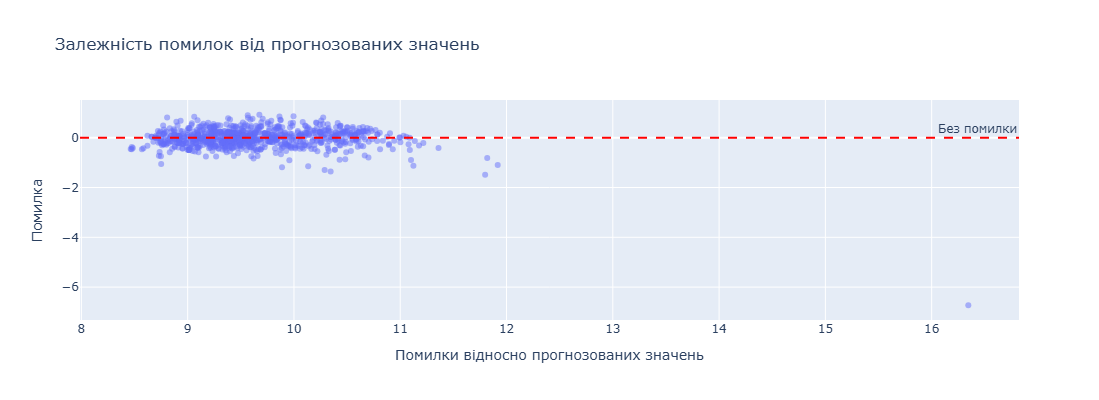

In [108]:
# Scatter plot: помилки vs прогнозовані значення
fig = px.scatter(
    x=y_test_pred,
    y=residuals,
    title='Залежність помилок від прогнозованих значень',
    labels={'x': 'Помилки відносно прогнозованих значень', 'y': 'Помилка'},
    opacity=0.5
)

# Додаємо горизонтальну лінію на 0
fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Без помилки")

fig.update_layout(height=400)
fig.show()

In [110]:
# Знаходимо пости з найбільшими помилками
errors_df = pd.DataFrame({
    'real': y_test.values,
    'predicted': y_test_pred,
    'error': np.abs(residuals)
})

# Топ-5 найбільших помилок
top_5 = errors_df.nlargest(5, 'error')
print("5 прогнозів з найбільшими помилками:")
print(top_5)

5 прогнозів з найбільшими помилками:
           real  predicted     error
4653   9.615872  16.344699  6.728827
275   10.308986  11.798764  1.489778
852    8.987322  10.345085  1.357763
549    8.987322  10.288783  1.301461
267    8.699681   9.887585  1.187903
